# Voting Classification - Soft Voting

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, classification_report,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

## Ler Dados

In [26]:
df_leads = pd.read_csv("./dataset/leads.csv")
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9074 non-null   str    
 1   Lead Source                             9074 non-null   str    
 2   Do Not Email                            9074 non-null   int64  
 3   Do Not Call                             9074 non-null   int64  
 4   Converted                               9074 non-null   int64  
 5   TotalVisits                             9074 non-null   float64
 6   Total Time Spent on Website             9074 non-null   int64  
 7   Page Views Per Visit                    9074 non-null   float64
 8   Last Activity                           9074 non-null   str    
 9   Search                                  9074 non-null   int64  
 10  Newspaper Article                       9074 non-null   int64  
 11  X 

In [27]:
df_leads.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,0,0,0,0.0,0,0.0,Page Visited on Website,0,0,0,0,0,0,0,Modified
1,API,Organic Search,0,0,0,5.0,674,2.5,Email Opened,0,0,0,0,0,0,0,Email Opened
2,Landing Page Submission,Direct Traffic,0,0,1,2.0,1532,2.0,Email Opened,0,0,0,0,0,0,1,Email Opened
3,Landing Page Submission,Direct Traffic,0,0,0,1.0,305,1.0,Unreachable,0,0,0,0,0,0,0,Modified
4,Landing Page Submission,Google,0,0,1,2.0,1428,1.0,Converted to Lead,0,0,0,0,0,0,0,Modified
5,API,Olark Chat,0,0,0,0.0,0,0.0,Olark Chat Conversation,0,0,0,0,0,0,0,Modified
6,Landing Page Submission,Google,0,0,1,2.0,1640,2.0,Email Opened,0,0,0,0,0,0,0,Modified
7,API,Olark Chat,0,0,0,0.0,0,0.0,Olark Chat Conversation,0,0,0,0,0,0,0,Modified
8,Landing Page Submission,Direct Traffic,0,0,0,2.0,71,2.0,Email Opened,0,0,0,0,0,0,1,Email Opened
9,API,Google,0,0,0,4.0,58,4.0,Email Opened,0,0,0,0,0,0,0,Email Opened


## Preparação dos Dados

In [28]:
preprocessor: ColumnTransformer = joblib.load("preprocessor.pkl")

In [29]:
X = df_leads.drop(columns=['Converted'])
y = df_leads['Converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

X_train = preprocessor.fit_transform(X_train).toarray()
X_test = preprocessor.transform(X_test).toarray()

In [30]:
X_test

array([[-0.28575686, -0.01660108, -0.28429878, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108, -0.67485989, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108, -0.67485989, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.28575686, -0.01660108,  0.69210397, ...,  0.        ,
         0.        ,  0.        ],
       [ 3.49947858, -0.01660108,  0.69210397, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108,  1.47322618, ...,  0.        ,
         0.        ,  0.        ]], shape=(1815, 68))

In [31]:
X_train

array([[-0.28575686, -0.01660108, -0.47957933, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108, -0.67485989, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108, -0.47957933, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.28575686, -0.01660108,  0.30154287, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108,  0.10626232, ...,  0.        ,
         0.        ,  0.        ],
       [-0.28575686, -0.01660108,  0.30154287, ...,  0.        ,
         0.        ,  0.        ]], shape=(7259, 68))

## Treinamento do Modelo

In [32]:
# Modelos
# OBS: SVC precisa do hiperparâmetro probability=True para dar as probabilidades ao fim
lr_model = LogisticRegression(random_state=51)
svc_model = SVC(kernel='linear', random_state=51, probability=True)
tree_model = DecisionTreeClassifier(random_state=51)

In [33]:
voting_model = VotingClassifier(
  estimators=[
    ('linear', lr_model),
    ('svc', svc_model),
    ('tree', tree_model),
  ],
  # Voting
  # |- Hard = Votação por predição.
  # |- Soft = Votação por probabilidade. 
  voting='soft',
)

In [34]:
voting_model.fit(X=X_train, y=y_train)

/home/pedro/.local/share/virtualenvs/7-voting-classificacao-LKHVC_yO/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('linear', ...), ('svc', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ndom_state=51), SVC(kernel='l...ndom_state=51), DecisionTreeC...ndom_state=51)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,68


## Análise de Métricas

In [35]:
y_pred = voting_model.predict(X=X_test)

In [36]:
accuracy = accuracy_score(y_pred=y_pred, y_true=y_test)
precision = precision_score(y_pred=y_pred, y_true=y_test)
recall = recall_score(y_pred=y_pred, y_true=y_test)
f1 = f1_score(y_pred=y_pred, y_true=y_test)
report = classification_report(y_pred=y_pred, y_true=y_test, digits=4)

In [37]:
print(f"Acurácia: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Acurácia: 0.7862258953168044
Precision: 0.7203125
Recall: 0.6880597014925374
F1-Score: 0.7038167938931298


In [38]:
print(report)

              precision    recall  f1-score   support

           0     0.8221    0.8437    0.8328      1145
           1     0.7203    0.6881    0.7038       670

    accuracy                         0.7862      1815
   macro avg     0.7712    0.7659    0.7683      1815
weighted avg     0.7845    0.7862    0.7852      1815



### Confusion Matrix

In [39]:
conf_matrix = confusion_matrix(y_pred=y_pred, y_true=y_test)

Text(0.5, 1.0, 'Matriz de Confusão')

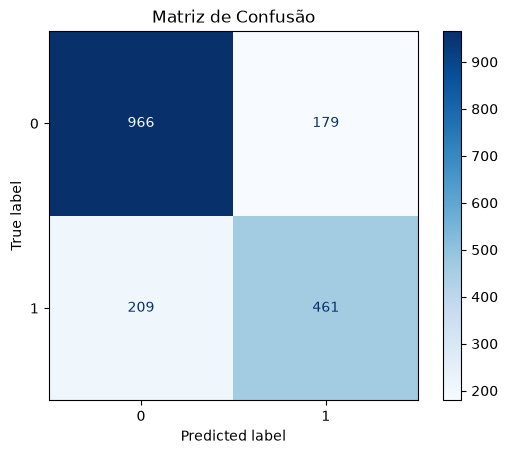

In [40]:
cmd = ConfusionMatrixDisplay(conf_matrix)
cmd.plot(
  cmap='Blues'
)
plt.title("Matriz de Confusão")

## Importâncias dos Modelos

In [41]:
importances = list()

for estimador in voting_model.estimators_:
    # Para modelos lineares.
    if hasattr(estimador, 'coef_'):
        importances.append(np.abs(estimador.coef_[0]))
    # Para modelos baseados em árvores.
    elif hasattr(estimador, 'feature_importances_'):
        importances.append(estimador.feature_importances_)
    else:
        print(f"Não foi possível carregar as importâncias do modelo {type(estimador).__name__}")

In [42]:
importances_mean = np.mean(importances, axis=0)

In [43]:
importances_mean_percentage = importances_mean / np.sum(importances_mean)

In [44]:
feature_names = preprocessor.get_feature_names_out()

In [45]:
df_importances = pd.DataFrame({ 'importance': importances_mean_percentage, 'feature': feature_names })
df_importances.sort_values(by='importance', ascending=True, inplace=True)

In [46]:
fig = px.bar(
  df_importances,
  x='importance',
  y='feature',
  title='Importância das Features (Voting Classifier)'
)

fig.update_layout(height=1280, width=1000)

## Propriedades do Modelo - Soft Voting

### Testar Estimadores
- Nesse caso 2 estimadores colocaram como classe 1.
- Contudo, a probabilidade média dos 3 modelos era maior para a classe 1. Portanto, a classe final é 1.

In [53]:
X_sample = X_test[7].reshape(1, -1)

log_probabilities = voting_model.named_estimators_['linear'].predict_proba(X_sample)
svc_probabilities = voting_model.named_estimators_['svc'].predict_proba(X_sample)
tree_probabilities = voting_model.named_estimators_['tree'].predict_proba(X_sample)

voting_probabilities = voting_model.predict_proba(X_sample)
result = voting_model.predict(X=X_sample)

In [54]:
print(f"Regressão Logística: {log_probabilities}")
print(f"SVC: {svc_probabilities}")
print(f"Árvore de Decisão: {tree_probabilities}")
print(f"Probabilidadede Votação: {voting_probabilities}")
print(f"Predição final: {result}")

Regressão Logística: [[0.67050795 0.32949205]]
SVC: [[0.69502844 0.30497156]]
Árvore de Decisão: [[0. 1.]]
Probabilidadede Votação: [[0.4551788 0.5448212]]
Predição final: [1]
